In [ ]:
!pip install -U ultralytics -q

import os, time, shutil, random, cv2, json
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import torch
from ultralytics import YOLO
from PIL import Image
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

# ── Folder khusus untuk eksperimen model YOLO26n ──────────
# Dibuat terpisah dari folder skripsi_yolo (YOLOv8n) supaya
# tidak tertimpa / tercampur dengan eksperimen sebelumnya.
DRIVE_DIR        = "/content/drive/MyDrive/skripsi_yolo26n"
CROWDHUMAN_DIR   = "/content/crowdhuman"
YOLO_DATASET_DIR = "/content/yolo_dataset_crowdhuman"

os.makedirs(DRIVE_DIR, exist_ok=True)

# Folder khusus eksperimen 5 seed
EXPERIMENT_DIR = f"{DRIVE_DIR}/experiments_5seed"
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

# ── Model dasar: YOLO26n ───────────────────────────────────
# Upload file 'yolo26n.pt' ke folder Drive di atas terlebih
# dahulu (DRIVE_DIR), lalu jalankan cell ini. Model akan
# dicek/disalin ke lokal Colab supaya loading lebih cepat.
MODEL_NAME       = "yolo26n"
MODEL_WEIGHTS_DRIVE = f"{DRIVE_DIR}/{MODEL_NAME}.pt"
MODEL_WEIGHTS_LOCAL = f"/content/{MODEL_NAME}.pt"

if os.path.exists(MODEL_WEIGHTS_DRIVE):
    shutil.copy2(MODEL_WEIGHTS_DRIVE, MODEL_WEIGHTS_LOCAL)
    print(f"✅ Bobot {MODEL_NAME}.pt disalin dari Drive ke lokal")
elif os.path.exists(MODEL_WEIGHTS_LOCAL):
    print(f"✅ Bobot {MODEL_NAME}.pt sudah ada di lokal")
else:
    print(f"⚠️ Bobot {MODEL_NAME}.pt belum ditemukan!")
    print(f"   Upload dulu ke: {MODEL_WEIGHTS_DRIVE}")
    print(f"   (atau ke {MODEL_WEIGHTS_LOCAL} langsung di sesi ini)")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nPyTorch : {torch.__version__}")
print(f"Device  : {device}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

# 5 seed yang akan digunakan
SEEDS = [42, 123, 256, 512, 999]
print(f"\nSeeds : {SEEDS}")
print(f"Jumlah eksperimen: {len(SEEDS)}")
print("✅ Setup selesai!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
⚠️ Bobot yolo26n.pt belum ditemukan!
   Upload dulu ke: /content/drive/MyDrive/skripsi_yolo26n/yolo26n.pt
   (atau ke /content/yolo26n.pt langsung di sesi ini)

PyTorch : 2.11.0+cu128
Device  : cuda
GPU     : Tesla T4

Seeds : [42, 123, 256, 512, 999]
Jumlah eksperimen: 5
✅ Setup selesai!


In [ ]:
os.makedirs(f"{CROWDHUMAN_DIR}/images", exist_ok=True)
os.makedirs(f"{CROWDHUMAN_DIR}/annotations", exist_ok=True)

# CrowdHuman didistribusikan resmi lewat Google Drive/Baidu (crowdhuman.org)
# yang tidak bisa di-wget langsung, sehingga digunakan mirror publik di
# Hugging Face (sshao0516/CrowdHuman) yang mendukung unduhan langsung.
HF_BASE = "https://huggingface.co/datasets/sshao0516/CrowdHuman/resolve/main"

# ── Anotasi (.odgt) ──────────────────────────────────────
if not os.path.exists(f"{CROWDHUMAN_DIR}/annotations/annotation_val.odgt"):
    print("Downloading anotasi CrowdHuman val...")
    !wget -c -q --show-progress \
         {HF_BASE}/annotation_val.odgt \
         -O {CROWDHUMAN_DIR}/annotations/annotation_val.odgt
    print("✅ annotation_val.odgt selesai!")
else:
    print("✅ annotation_val.odgt sudah ada!")

if not os.path.exists(f"{CROWDHUMAN_DIR}/annotations/annotation_train.odgt"):
    print("Downloading anotasi CrowdHuman train...")
    !wget -c -q --show-progress \
         {HF_BASE}/annotation_train.odgt \
         -O {CROWDHUMAN_DIR}/annotations/annotation_train.odgt
    print("✅ annotation_train.odgt selesai!")
else:
    print("✅ annotation_train.odgt sudah ada!")

# ── Citra Validasi (CrowdHuman_val.zip, ±2,5 GB, 4.370 citra) ──
if not os.path.exists(f"{CROWDHUMAN_DIR}/images/val"):
    print("Downloading CrowdHuman_val.zip...")
    !wget -c -q --show-progress \
         {HF_BASE}/CrowdHuman_val.zip \
         -O /content/CrowdHuman_val.zip
    !unzip -o -q /content/CrowdHuman_val.zip -d /content/ch_val_tmp/
    os.makedirs(f"{CROWDHUMAN_DIR}/images/val", exist_ok=True)
    !mv /content/ch_val_tmp/Images/* {CROWDHUMAN_DIR}/images/val/
    !rm -rf /content/CrowdHuman_val.zip /content/ch_val_tmp
    print(f"✅ val: {len(os.listdir(CROWDHUMAN_DIR+'/images/val')):,}")
else:
    print(f"✅ val sudah ada: {len(os.listdir(CROWDHUMAN_DIR+'/images/val')):,}")

# ── Citra Train (3 bagian, ±8,4 GB total, 15.000 citra) ──
if not os.path.exists(f"{CROWDHUMAN_DIR}/images/train"):
    os.makedirs(f"{CROWDHUMAN_DIR}/images/train", exist_ok=True)
    for part in ["01", "02", "03"]:
        print(f"Downloading CrowdHuman_train{part}.zip...")
        !wget -c -q --show-progress \
             {HF_BASE}/CrowdHuman_train{part}.zip \
             -O /content/CrowdHuman_train{part}.zip
        !unzip -o -q /content/CrowdHuman_train{part}.zip -d /content/ch_train_tmp/
        !mv /content/ch_train_tmp/Images/* {CROWDHUMAN_DIR}/images/train/
        !rm -rf /content/CrowdHuman_train{part}.zip /content/ch_train_tmp
        print(f"  ✅ train{part} selesai "
              f"({len(os.listdir(CROWDHUMAN_DIR+'/images/train')):,} citra terkumpul)")
    print(f"✅ train: {len(os.listdir(CROWDHUMAN_DIR+'/images/train')):,}")
else:
    print(f"✅ train sudah ada: {len(os.listdir(CROWDHUMAN_DIR+'/images/train')):,}")

CROWDHUMAN_TRAIN_IMG = f"{CROWDHUMAN_DIR}/images/train"
CROWDHUMAN_VAL_IMG   = f"{CROWDHUMAN_DIR}/images/val"
CROWDHUMAN_TRAIN_ANN = f"{CROWDHUMAN_DIR}/annotations/annotation_train.odgt"
CROWDHUMAN_VAL_ANN   = f"{CROWDHUMAN_DIR}/annotations/annotation_val.odgt"
print("\n✅ CrowdHuman siap!")


/content/crowdhuman 100%[===================>]  22.24M  36.8MB/s    in 0.6s    
✅ annotation_val.odgt selesai!
/content/crowdhuman 100%[===================>]  76.31M  11.4MB/s    in 8.1s    
✅ annotation_train.odgt selesai!
/content/CrowdHuman 100%[===================>]   2.32G   115MB/s    in 6m 17s  
✅ val: 4,370
/content/CrowdHuman 100%[===================>]   2.77G  41.4MB/s    in 51s     
  ✅ train01 selesai (5,000 citra terkumpul)
/content/CrowdHuman 100%[===================>]   2.88G   126MB/s    in 93s     
  ✅ train02 selesai (10,000 citra terkumpul)
/content/CrowdHuman 100%[===================>]   2.15G  63.7MB/s    in 45s     
  ✅ train03 selesai (15,000 citra terkumpul)
✅ train: 15,000

✅ CrowdHuman siap!


In [ ]:
PERSON_CLASSES = {1, 2}  # tidak dipakai lagi (khusus VisDrone), disisakan untuk referensi

YOLO_TRAIN_IMG = f"{YOLO_DATASET_DIR}/images/train"
YOLO_TRAIN_LBL = f"{YOLO_DATASET_DIR}/labels/train"
YOLO_VAL_IMG   = f"{YOLO_DATASET_DIR}/images/val"
YOLO_VAL_LBL   = f"{YOLO_DATASET_DIR}/labels/val"

for d in [YOLO_TRAIN_IMG, YOLO_TRAIN_LBL,
          YOLO_VAL_IMG,   YOLO_VAL_LBL]:
    os.makedirs(d, exist_ok=True)


def convert_crowdhuman(odgt_file, img_dir, out_img,
                        out_lbl, max_images=None,
                        prefix="ch_"):
    """
    Konversi anotasi CrowdHuman (.odgt) ke format YOLO.

    Menggunakan 'fbox' (full-body box) -- bukan 'vbox' (visible box
    saja) -- karena penelitian ini berfokus pada full body detection:
    model tetap dilatih memprediksi luas penuh tubuh manusia meskipun
    sebagian tertutup (occlusion), bukan hanya bagian yang tampak.
    Box dengan tag "mask" (area crowd/ignore) dan box yang ditandai
    extra.ignore=1 dilewati karena bukan instans person yang valid.
    """
    print(f"Konversi CrowdHuman...")
    with open(odgt_file) as f:
        lines = f.readlines()
    if max_images:
        lines = lines[:max_images]

    converted = 0
    for i, line in enumerate(lines):
        ann      = json.loads(line)
        img_file = ann["ID"] + ".jpg"
        src      = os.path.join(img_dir, img_file)
        if not os.path.exists(src):
            continue

        img  = Image.open(src)
        W, H = img.size

        boxes = []
        for gt in ann.get("gtboxes", []):
            if gt.get("tag") != "person":
                continue
            if gt.get("extra", {}).get("ignore", 0) == 1:
                continue
            x, y, w, h = gt["fbox"]
            x, y = max(0, x), max(0, y)
            w, h = min(w, W - x), min(h, H - y)
            if w < 5 or h < 5:
                continue
            cx = max(0, min(1, (x + w/2) / W))
            cy = max(0, min(1, (y + h/2) / H))
            nw = max(0, min(1, w / W))
            nh = max(0, min(1, h / H))
            boxes.append((cx, cy, nw, nh))

        if not boxes:
            continue

        dst = prefix + img_file
        shutil.copy2(src, os.path.join(out_img, dst))
        lbl = prefix + Path(img_file).stem + ".txt"
        with open(os.path.join(out_lbl, lbl), "w") as f:
            for cx, cy, nw, nh in boxes:
                f.write(f"0 {cx:.6f} {cy:.6f} "
                        f"{nw:.6f} {nh:.6f}\n")
        converted += 1
        if (i+1) % 1000 == 0:
            print(f"  {i+1:,}/{len(lines):,}")

    print(f"  ✅ {converted:,} gambar")
    return converted


# Cek apakah sudah dikonversi
n_train = len(os.listdir(YOLO_TRAIN_IMG))
n_val   = len(os.listdir(YOLO_VAL_IMG))

# Dataset sekarang murni CrowdHuman (VisDrone tidak digunakan lagi)
# Train: 15.000 citra, Val: 4.370 citra (sesuai jumlah asli CrowdHuman)
TARGET_TRAIN_COUNT = 15000
TARGET_VAL_COUNT   = 4370

if n_train >= TARGET_TRAIN_COUNT - 100:
    print(f"✅ Train sudah ada: {n_train:,} (target ~{TARGET_TRAIN_COUNT:,})")
else:
    print(f"Dataset train saat ini {n_train:,}, bukan target {TARGET_TRAIN_COUNT:,}. Memulai konversi ulang...")
    if os.path.exists(YOLO_TRAIN_IMG):
        shutil.rmtree(YOLO_TRAIN_IMG)
        os.makedirs(YOLO_TRAIN_IMG)
    if os.path.exists(YOLO_TRAIN_LBL):
        shutil.rmtree(YOLO_TRAIN_LBL)
        os.makedirs(YOLO_TRAIN_LBL)

    ch_train_converted = convert_crowdhuman(
        CROWDHUMAN_TRAIN_ANN, CROWDHUMAN_TRAIN_IMG,
        YOLO_TRAIN_IMG, YOLO_TRAIN_LBL,
        max_images=None, prefix="ch_")

    print(f"Total gambar train yang dikonversi: {ch_train_converted:,}")

if n_val >= TARGET_VAL_COUNT - 100:
    print(f"✅ Val sudah ada: {n_val:,}")
else:
    convert_crowdhuman(
        CROWDHUMAN_VAL_ANN, CROWDHUMAN_VAL_IMG,
        YOLO_VAL_IMG, YOLO_VAL_LBL,
        max_images=None, prefix="ch_")

print(f"\n✅ Dataset siap!")
print(f"  Train: {len(os.listdir(YOLO_TRAIN_IMG)):,}")
print(f"  Val  : {len(os.listdir(YOLO_VAL_IMG)):,}")


Dataset train saat ini 0, bukan target 15,000. Memulai konversi ulang...
Konversi CrowdHuman...
  1,000/15,000
  2,000/15,000
  3,000/15,000
  4,000/15,000
  5,000/15,000
  6,000/15,000
  7,000/15,000
  8,000/15,000
  9,000/15,000
  10,000/15,000
  11,000/15,000
  12,000/15,000
  13,000/15,000
  14,000/15,000
  15,000/15,000
  ✅ 15,000 gambar
Total gambar train yang dikonversi: 15,000
Konversi CrowdHuman...
  1,000/4,370
  2,000/4,370
  3,000/4,370
  4,000/4,370
  ✅ 4,370 gambar

✅ Dataset siap!
  Train: 15,000
  Val  : 4,370


In [ ]:
YAML_PATH = f"{DRIVE_DIR}/dataset_crowdhuman.yaml"

yaml_content = f"""
path: {YOLO_DATASET_DIR}
train: images/train
val: images/val
nc: 1
names:
  0: person
"""
with open(YAML_PATH, "w") as f:
    f.write(yaml_content)
print("✅ dataset_crowdhuman.yaml dibuat!")
print(open(YAML_PATH).read())


✅ dataset_crowdhuman.yaml dibuat!

path: /content/yolo_dataset_crowdhuman
train: images/train
val: images/val
nc: 1
names:
  0: person



In [ ]:
def set_seed(seed):
    """Set semua seed untuk reproducibility"""
    import random
    import numpy as np
    import torch

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['PYTHONHASHSEED']       = str(seed)
    print(f"✅ Seed {seed} diset!")


def get_experiment_status():
    """Cek seed mana yang sudah selesai"""
    status = {}
    for seed in SEEDS:
        best = f"{EXPERIMENT_DIR}/seed_{seed}/weights/best.pt"
        last = f"{EXPERIMENT_DIR}/seed_{seed}/weights/last.pt"
        if os.path.exists(best):
            size = os.path.getsize(best)
            status[seed] = f"✅ Selesai ({size/1e6:.1f} MB)"
        elif os.path.exists(last):
            status[seed] = "⏳ Checkpoint ada (belum selesai)"
        else:
            status[seed] = "❌ Belum dimulai"

    print("\n" + "="*50)
    print(f"STATUS EKSPERIMEN 5 SEED — {MODEL_NAME.upper()}")
    print("="*50)
    for seed, stat in status.items():
        print(f"  Seed {seed:>4} : {stat}")
    print("="*50)
    return status


# Cek status awal
get_experiment_status()



STATUS EKSPERIMEN 5 SEED — YOLO26N
  Seed   42 : ✅ Selesai (20.7 MB)
  Seed  123 : ✅ Selesai (20.7 MB)
  Seed  256 : ✅ Selesai (20.7 MB)
  Seed  512 : ✅ Selesai (20.7 MB)
  Seed  999 : ✅ Selesai (20.7 MB)


{42: '✅ Selesai (20.7 MB)',
 123: '✅ Selesai (20.7 MB)',
 256: '✅ Selesai (20.7 MB)',
 512: '✅ Selesai (20.7 MB)',
 999: '✅ Selesai (20.7 MB)'}

In [ ]:
import os

# Hitung estimasi waktu
n_train    = len(os.listdir(YOLO_TRAIN_IMG))
n_val      = len(os.listdir(YOLO_VAL_IMG))
batch_size = 16
epochs     = 50

n_batch_per_epoch = n_train // batch_size
# Asumsi ~0.3 detik per batch di GPU T4
sec_per_epoch     = n_batch_per_epoch * 0.3
total_sec         = sec_per_epoch * epochs
total_jam         = total_sec / 3600

print("="*50)
print("ESTIMASI WAKTU TRAINING")
print("="*50)
print(f"Model            : {MODEL_NAME}")
print(f"Dataset train    : {n_train:,} gambar")
print(f"Dataset val      : {n_val:,} gambar")
print(f"Batch per epoch  : {n_batch_per_epoch:,}")
print(f"Total epoch      : {epochs}")
print(f"Estimasi/epoch   : {sec_per_epoch/60:.1f} menit")
print(f"Total estimasi   : {total_jam:.1f} jam")
print("="*50)

if total_jam > 10:
    print("⚠️ Lebih dari 10 jam!")
    print("   Pertimbangkan kurangi epoch lagi")
elif total_jam > 5:
    print("⏳ 5-10 jam — masih bisa di satu session")
else:
    print("✅ Di bawah 5 jam — aman di satu session")


ESTIMASI WAKTU TRAINING
Model            : yolo26n
Dataset train    : 15,000 gambar
Dataset val      : 4,370 gambar
Batch per epoch  : 937
Total epoch      : 50
Estimasi/epoch   : 4.7 menit
Total estimasi   : 3.9 jam
✅ Di bawah 5 jam — aman di satu session


In [ ]:
def train_single_seed(seed, yaml_path, device,
                      resume=True):
    """
    Train satu seed dengan model dasar YOLO26n
    Return: hasil metrics atau None kalau gagal
    """
    exp_name  = f"seed_{seed}"
    exp_dir   = f"{EXPERIMENT_DIR}/{exp_name}"
    best_ckpt = f"{exp_dir}/weights/best.pt"
    last_ckpt = f"{exp_dir}/weights/last.pt"

    print(f"\n{'='*60}")
    print(f"EKSPERIMEN SEED {seed} — {MODEL_NAME.upper()}")
    print(f"{'='*60}")

    # Update yaml dengan path lokal
    yaml_content = f"""
path: {YOLO_DATASET_DIR}
train: images/train
val: images/val
nc: 1
names:
  0: person
"""
    with open(yaml_path, "w") as f:
        f.write(yaml_content)

    # Set seed
    set_seed(seed)

    try:
        if os.path.exists(best_ckpt):
            print(f"✅ Seed {seed} sudah selesai, skip training")
            model = YOLO(best_ckpt)

        elif resume and os.path.exists(last_ckpt):
            print(f"Resume dari checkpoint...")
            model   = YOLO(last_ckpt)
            # Explicitly set epochs on the trainer's arguments to override checkpoint metadata
            model.trainer.args.epochs = 50
            results = model.train(resume=True)

        else:
            print(f"Training baru dari pretrained {MODEL_NAME}.pt...")
            model = YOLO(MODEL_WEIGHTS_LOCAL)
            set_seed(seed)  # set ulang setelah load

            results = model.train(
                data         = yaml_path,
                epochs       = 50,
                imgsz        = 640,
                batch        = 16,
                device       = device,
                workers      = 2,
                patience     = 3,
                save         = True,
                project      = EXPERIMENT_DIR,
                name         = exp_name,
                exist_ok     = True,
                save_period  = 10,
                seed         = seed,  # ← seed YOLO

                # Augmentasi
                fliplr       = 0.5,
                flipud       = 0.0,
                mosaic       = 1.0,
                mixup        = 0.1,
                copy_paste   = 0.1,
                degrees      = 10.0,
                scale        = 0.7,
                translate    = 0.1,
                hsv_h        = 0.015,
                hsv_s        = 0.7,
                hsv_v        = 0.4,

                # Learning rate
                lr0          = 0.001,
                lrf          = 0.01,
                warmup_epochs= 5,
                optimizer    = "AdamW",
                weight_decay = 0.0005,
                verbose      = False,  # kurangi output
            )

        # Evaluasi model terbaik
        print(f"\nEvaluasi seed {seed}...")
        model = YOLO(best_ckpt)

        # Update yaml untuk evaluasi
        with open(yaml_path, "w") as f:
            f.write(yaml_content)

        metrics = model.val(
            data    = yaml_path,
            imgsz   = 640,
            batch   = 16,
            device  = device,
            conf    = 0.25,
            iou     = 0.5,
            verbose = False)

        result = {
            "seed"     : seed,
            "precision": float(metrics.box.p.mean()),
            "recall"   : float(metrics.box.r.mean()),
            "map50"    : float(metrics.box.map50),
            "map"      : float(metrics.box.map),
        }

        # Hitung FPS
        import time
        val_imgs = os.listdir(YOLO_VAL_IMG)[:30]
        times    = []
        for fn in val_imgs:
            img_path = os.path.join(YOLO_VAL_IMG, fn)
            start    = time.time()
            model.predict(
                img_path,
                conf    = 0.25,
                iou     = 0.5,
                classes = [0],
                verbose = False)
            times.append(time.time() - start)
        result["fps"] = 1.0 / (sum(times)/len(times))

        print(f"\n✅ Seed {seed} selesai!")
        print(f"   Precision : {result['precision']*100:.2f}%")
        print(f"   Recall    : {result['recall']*100:.2f}%")
        print(f"   mAP@0.5   : {result['map50']*100:.2f}%")
        print(f"   FPS       : {result['fps']:.1f}")

        # Simpan hasil seed ini ke Drive
        seed_result_path = f"{EXPERIMENT_DIR}/result_seed_{seed}.json"
        with open(seed_result_path, "w") as f:
            json.dump(result, f, indent=2)
        print(f"   Tersimpan : {seed_result_path}")

        return result

    except Exception as e:
        print(f"❌ Error pada seed {seed}: {e}")
        return None


# ── Jalankan semua 5 seed ──────────────────
print("="*60)
print("MULAI EKSPERIMEN 5 SEED")
print(f"Seeds: {SEEDS}")
print(f"Model: {MODEL_NAME.upper()}")
print(f"Epochs: 50")
print(f"Dataset: CrowdHuman (tanpa VisDrone)")
print("="*60)

all_results = []

# Cek hasil yang sudah ada
for seed in SEEDS:
    result_path = f"{EXPERIMENT_DIR}/result_seed_{seed}.json"
    if os.path.exists(result_path):
        with open(result_path) as f:
            result = json.load(f)
        print(f"✅ Seed {seed} sudah ada, load dari file")
        all_results.append(result)
    else:
        result = train_single_seed(
            seed     = seed,
            yaml_path= YAML_PATH,
            device   = device,
            resume   = True)
        if result:
            all_results.append(result)

print(f"\n✅ Semua eksperimen selesai!")
print(f"Total hasil: {len(all_results)}/5")


MULAI EKSPERIMEN 5 SEED
Seeds: [42, 123, 256, 512, 999]
Model: YOLO26N
Epochs: 50
Dataset: CrowdHuman (tanpa VisDrone)
✅ Seed 42 sudah ada, load dari file
✅ Seed 123 sudah ada, load dari file
✅ Seed 256 sudah ada, load dari file
✅ Seed 512 sudah ada, load dari file

EKSPERIMEN SEED 999 — YOLO26N
✅ Seed 999 diset!
✅ Seed 999 sudah selesai, skip training

Evaluasi seed 999...
Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2534.2±319.4 MB/s, size: 393.8 KB)
val: Scanning /content/yolo_dataset_crowdhuman/labels/val... 4370 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4370/4370 1.2Kit/s 3.6s
val: New cache created: /content/yolo_dataset_crowdhuman/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 274/274 3.2it/s 1:26
                   all    

In [ ]:
import numpy as np
import json

# Load semua hasil kalau belum ada di memory
if len(all_results) < len(SEEDS):
    all_results = []
    for seed in SEEDS:
        result_path = f"{EXPERIMENT_DIR}/result_seed_{seed}.json"
        if os.path.exists(result_path):
            with open(result_path) as f:
                all_results.append(json.load(f))

print(f"Total hasil tersedia: {len(all_results)}/5")

if len(all_results) == 0:
    print("❌ Belum ada hasil, jalankan training dulu")
else:
    # Ekstrak nilai per metrik
    metrics_data = {
        "precision": [r["precision"] for r in all_results],
        "recall"   : [r["recall"]    for r in all_results],
        "map50"    : [r["map50"]     for r in all_results],
        "map"      : [r["map"]       for r in all_results],
        "fps"      : [r["fps"]       for r in all_results],
    }

    # Hitung rerata dan std dev
    stats = {}
    for metric, values in metrics_data.items():
        arr = np.array(values)
        stats[metric] = {
            "values" : values,
            "mean"   : float(np.mean(arr)),
            "std"    : float(np.std(arr)),
            "min"    : float(np.min(arr)),
            "max"    : float(np.max(arr)),
        }

    # ── Tampilkan hasil ────────────────────
    print("\n" + "="*65)
    print(f"HASIL EKSPERIMEN 5 SEED — {MODEL_NAME.upper()} — CROWDHUMAN")
    print("="*65)

    # Tabel per seed
    print(f"\n{'Seed':<8} {'Precision':>10} "
          f"{'Recall':>8} {'mAP@0.5':>9} "
          f"{'mAP':>8} {'FPS':>7}")
    print("-"*55)
    for r in all_results:
        print(f"{r['seed']:<8} "
              f"{r['precision']*100:>9.2f}% "
              f"{r['recall']*100:>7.2f}% "
              f"{r['map50']*100:>8.2f}% "
              f"{r['map']*100:>7.2f}% "
              f"{r['fps']:>6.1f}")

    print("-"*55)

    # Rerata dan std dev
    print(f"\n{'Rerata':<8} "
          f"{stats['precision']['mean']*100:>9.2f}% "
          f"{stats['recall']['mean']*100:>7.2f}% "
          f"{stats['map50']['mean']*100:>8.2f}% "
          f"{stats['map']['mean']*100:>7.2f}% "
          f"{stats['fps']['mean']:>6.1f}")
    print(f"{'Std Dev':<8} "
          f"{stats['precision']['std']*100:>9.2f}% "
          f"{stats['recall']['std']*100:>7.2f}% "
          f"{stats['map50']['std']*100:>8.2f}% "
          f"{stats['map']['std']*100:>7.2f}% "
          f"{stats['fps']['std']:>6.1f}")
    print("="*65)

    # Simpan summary ke Drive
    summary = {"stats": stats, "per_seed": all_results}
    summary_path = f"{EXPERIMENT_DIR}/summary_5seed.json"
    with open(summary_path, "w") as f:
        json.dump(summary, f, indent=2)
    print(f"\n✅ Summary tersimpan: {summary_path}")


Total hasil tersedia: 5/5

HASIL EKSPERIMEN 5 SEED — YOLO26N — CROWDHUMAN

Seed      Precision   Recall   mAP@0.5      mAP     FPS
-------------------------------------------------------
42           78.91%   68.68%    65.83%   40.70%   14.8
123          78.63%   65.63%    62.71%   37.95%   16.8
256          79.70%   69.68%    67.81%   42.33%   23.7
512          79.61%   69.32%    66.89%   41.76%   23.3
999          79.95%   69.92%    67.91%   42.38%   22.7
-------------------------------------------------------

Rerata       79.36%   68.64%    66.23%   41.02%   20.3
Std Dev       0.50%    1.57%     1.91%    1.65%    3.7

✅ Summary tersimpan: /content/drive/MyDrive/skripsi_yolo26n/experiments_5seed/summary_5seed.json


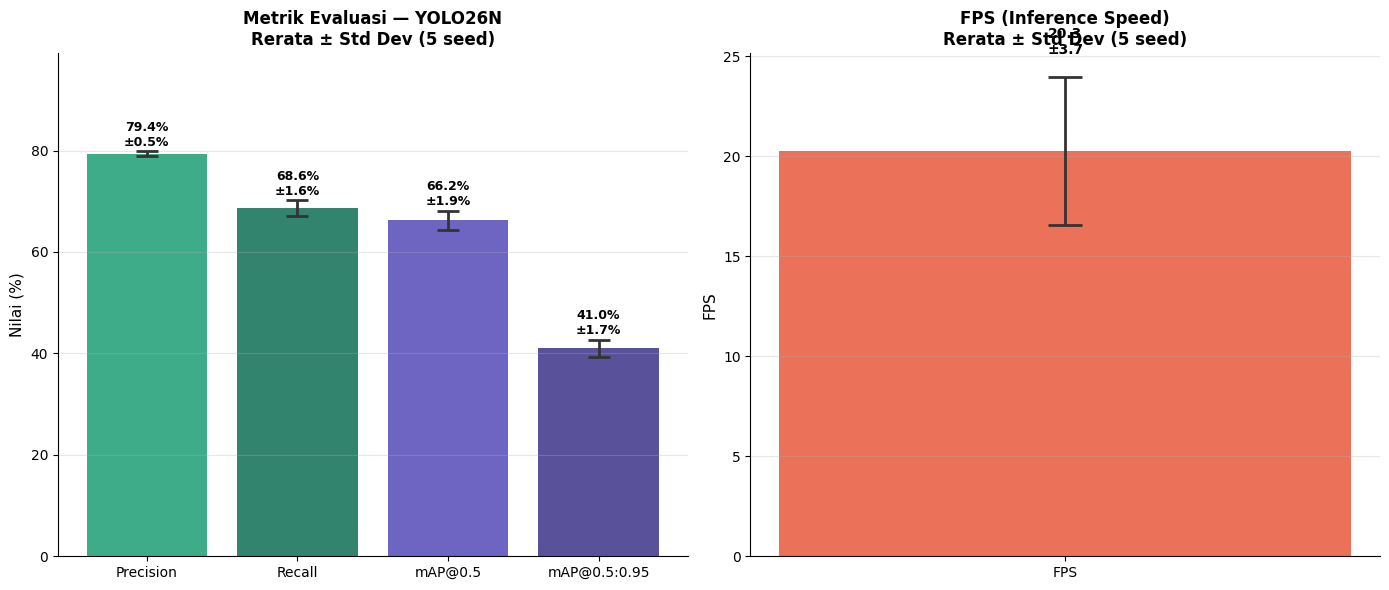

✅ Plot tersimpan: /content/drive/MyDrive/skripsi_yolo26n/experiments_5seed/plot_hasil_5seed.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Load data
summary_path = f"{EXPERIMENT_DIR}/summary_5seed.json"
if not os.path.exists(summary_path):
    print("❌ Jalankan cell agregasi hasil dulu")
else:
    with open(summary_path) as f:
        summary = json.load(f)

    stats    = summary["stats"]
    all_res  = summary["per_seed"]

    # ── Plot 1: Bar chart dengan error bar ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Metrik akurasi
    metrics_acc = ["precision", "recall", "map50", "map"]
    labels_acc  = ["Precision", "Recall",
                   "mAP@0.5", "mAP@0.5:0.95"]
    means_acc   = [stats[m]["mean"]*100
                   for m in metrics_acc]
    stds_acc    = [stats[m]["std"]*100
                   for m in metrics_acc]

    bars = axes[0].bar(
        labels_acc, means_acc,
        yerr    = stds_acc,
        capsize = 8,
        color   = ['#1D9E75','#0F6E56',
                   '#534AB7','#3C3489'],
        alpha   = 0.85,
        error_kw= dict(elinewidth=2,
                       ecolor='#333333',
                       capthick=2))

    # Tambah nilai di atas bar
    for bar, mean, std in zip(
            bars, means_acc, stds_acc):
        axes[0].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + std + 0.5,
            f"{mean:.1f}%\n±{std:.1f}%",
            ha='center', va='bottom',
            fontsize=9, fontweight='bold')

    axes[0].set_title(
        f"Metrik Evaluasi — {MODEL_NAME.upper()}\n"
        "Rerata ± Std Dev (5 seed)",
        fontsize=12, fontweight='bold')
    axes[0].set_ylabel("Nilai (%)", fontsize=11)
    axes[0].set_ylim(0, max(means_acc) * 1.25)
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    # FPS chart
    fps_mean = stats["fps"]["mean"]
    fps_std  = stats["fps"]["std"]

    axes[1].bar(
        ["FPS"], [fps_mean],
        yerr    = [fps_std],
        capsize = 12,
        color   = '#E8593C',
        alpha   = 0.85,
        error_kw= dict(elinewidth=2,
                       ecolor='#333333',
                       capthick=2))
    axes[1].text(
        0, fps_mean + fps_std + 1,
        f"{fps_mean:.1f}\n±{fps_std:.1f}",
        ha='center', va='bottom',
        fontsize=10, fontweight='bold')
    axes[1].set_title(
        "FPS (Inference Speed)\nRerata ± Std Dev (5 seed)",
        fontsize=12, fontweight='bold')
    axes[1].set_ylabel("FPS", fontsize=11)
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    plt.tight_layout()
    plot_path = f"{EXPERIMENT_DIR}/plot_hasil_5seed.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Plot tersimpan: {plot_path}")


In [ ]:
import json
import numpy as np

summary_path = f"{EXPERIMENT_DIR}/summary_5seed.json"
with open(summary_path) as f:
    summary = json.load(f)

stats   = summary["stats"]
all_res = summary["per_seed"]

print("="*70)
print(f"TABEL HASIL EKSPERIMEN 5 SEED — {MODEL_NAME.upper()}")
print("Siap disalin ke laporan skripsi")
print("="*70)

# Tabel lengkap
print(f"\n{'No':<4} {'Seed':<8} {'Precision':>12} "
      f"{'Recall':>9} {'mAP@0.5':>10} "
      f"{'mAP@0.5:0.95':>14} {'FPS':>7}")
print("-"*70)

for i, r in enumerate(all_res, 1):
    print(f"{i:<4} {r['seed']:<8} "
          f"{r['precision']*100:>11.2f}% "
          f"{r['recall']*100:>8.2f}% "
          f"{r['map50']*100:>9.2f}% "
          f"{r['map']*100:>13.2f}% "
          f"{r['fps']:>6.1f}")

print("-"*70)
print(f"{'':4} {'Rerata':<8} "
      f"{stats['precision']['mean']*100:>11.2f}% "
      f"{stats['recall']['mean']*100:>8.2f}% "
      f"{stats['map50']['mean']*100:>9.2f}% "
      f"{stats['map']['mean']*100:>13.2f}% "
      f"{stats['fps']['mean']:>6.1f}")
print(f"{'':4} {'Std Dev':<8} "
      f"{stats['precision']['std']*100:>11.2f}% "
      f"{stats['recall']['std']*100:>8.2f}% "
      f"{stats['map50']['std']*100:>9.2f}% "
      f"{stats['map']['std']*100:>13.2f}% "
      f"{stats['fps']['std']:>6.1f}")
print("="*70)

# Format ringkas untuk abstrak/kesimpulan
print("\n📋 FORMAT RINGKAS UNTUK ABSTRAK/KESIMPULAN:")
print("-"*50)
metrics_label = [
    ("precision", "Precision",    True),
    ("recall",    "Recall",       True),
    ("map50",     "mAP@0.5",      True),
    ("map",       "mAP@0.5:0.95", True),
    ("fps",       "FPS",          False),
]
for key, label, is_pct in metrics_label:
    m    = stats[key]["mean"]
    s    = stats[key]["std"]
    mult = 100 if is_pct else 1
    unit = "%" if is_pct else ""
    print(f"  {label:<16}: "
          f"{m*mult:.2f}{unit} "
          f"± {s*mult:.2f}{unit}")

# Simpan tabel ke txt
tabel_path = f"{EXPERIMENT_DIR}/tabel_hasil_skripsi.txt"
with open(tabel_path, "w") as f:
    f.write(f"TABEL HASIL EKSPERIMEN 5 SEED — {MODEL_NAME.upper()} (CrowdHuman)\n")
    f.write("="*70 + "\n")
    for i, r in enumerate(all_res, 1):
        f.write(f"{i:<4} {r['seed']:<8} "
                f"{r['precision']*100:>11.2f}% "
                f"{r['recall']*100:>8.2f}% "
                f"{r['map50']*100:>9.2f}% "
                f"{r['map']*100:>13.2f}% "
                f"{r['fps']:>6.1f}\n")
    f.write("-"*70 + "\n")
    for key, label, is_pct in metrics_label:
        m    = stats[key]["mean"]
        s    = stats[key]["std"]
        mult = 100 if is_pct else 1
        unit = "%" if is_pct else ""
        f.write(f"  {label:<16}: {m*mult:.2f}{unit} ± {s*mult:.2f}{unit}\n")
print(f"\n✅ Tabel tersimpan: {tabel_path}")


TABEL HASIL EKSPERIMEN 5 SEED — YOLO26N
Siap disalin ke laporan skripsi

No   Seed        Precision    Recall    mAP@0.5   mAP@0.5:0.95     FPS
----------------------------------------------------------------------
1    42             78.91%    68.68%     65.83%         40.70%   14.8
2    123            78.63%    65.63%     62.71%         37.95%   16.8
3    256            79.70%    69.68%     67.81%         42.33%   23.7
4    512            79.61%    69.32%     66.89%         41.76%   23.3
5    999            79.95%    69.92%     67.91%         42.38%   22.7
----------------------------------------------------------------------
     Rerata         79.36%    68.64%     66.23%         41.02%   20.3
     Std Dev         0.50%     1.57%      1.91%          1.65%    3.7

📋 FORMAT RINGKAS UNTUK ABSTRAK/KESIMPULAN:
--------------------------------------------------
  Precision       : 79.36% ± 0.50%
  Recall          : 68.64% ± 1.57%
  mAP@0.5         : 66.23% ± 1.91%
  mAP@0.5:0.95    : 41.0

konversi onnx

In [ ]:
!pip install -U ultralytics -q

import os
import cv2
import time
import torch
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from ultralytics import YOLO
from PIL import Image
from google.colab import drive, files

drive.mount("/content/drive")

DRIVE_DIR = "/content/drive/MyDrive/skripsi_yolo26n"
MODEL_NAME = "yolo26n"
device    = "cuda" if torch.cuda.is_available() \
            else "cpu"

print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

# ── Pilih model terbaik dari 5 seed ────────
# Sesuaikan BEST_SEED dengan seed yang memberikan mAP tertinggi
# pada eksperimenmu (lihat tabel hasil di cell sebelumnya).
BEST_SEED  = 999
BEST_CKPT  = f"{DRIVE_DIR}/experiments_5seed/" \
             f"seed_{BEST_SEED}/weights/best.pt"

if os.path.exists(BEST_CKPT):
    model = YOLO(BEST_CKPT)
    print(f"✅ Model dimuat: {BEST_CKPT}")
else:
    print("❌ Model tidak ditemukan!")
    print(f"   Cek path: {BEST_CKPT}")

os.makedirs("/content/demo_output", exist_ok=True)
print("✅ Setup selesai!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device : cuda
GPU    : Tesla T4
✅ Model dimuat: /content/drive/MyDrive/skripsi_yolo26n/experiments_5seed/seed_999/weights/best.pt
✅ Setup selesai!


In [ ]:
!pip install -U ultralytics -q
!pip install onnxruntime -q

import os
import cv2
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from ultralytics import YOLO
from google.colab import drive, files

drive.mount("/content/drive")

DRIVE_DIR  = "/content/drive/MyDrive/skripsi_yolo26n"
BEST_CKPT  = f"{DRIVE_DIR}/experiments_5seed/" \
             f"seed_999/weights/best.pt"

device = "cuda" if torch.cuda.is_available() \
         else "cpu"
print(f"Device : {device}")

model = YOLO(BEST_CKPT)
print(f"✅ Model PyTorch dimuat!")
print(f"   Path: {BEST_CKPT}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device : cuda
✅ Model PyTorch dimuat!
   Path: /content/drive/MyDrive/skripsi_yolo26n/experiments_5seed/seed_999/weights/best.pt


In [ ]:
import os

ONNX_PATH = f"{DRIVE_DIR}/best_model.onnx"

print("Konversi PyTorch → ONNX...")
print("⚠️ Estimasi 1-2 menit...")

# Export ke ONNX
exported = model.export(
    format   = "onnx",
    imgsz    = 640,
    dynamic  = False,   # fixed input size
    simplify = True,    # simplify graph
    opset    = 12,      # kompatibilitas luas
)

# Pindahkan ke Drive
import shutil
local_onnx = str(exported)  # path hasil export
if os.path.exists(local_onnx):
    shutil.copy(local_onnx, ONNX_PATH)
    size_pt   = os.path.getsize(BEST_CKPT)
    size_onnx = os.path.getsize(ONNX_PATH)
    print(f"\n✅ Konversi berhasil!")
    print(f"   PyTorch  : {size_pt/1e6:.2f} MB")
    print(f"   ONNX     : {size_onnx/1e6:.2f} MB")
    print(f"   Tersimpan: {ONNX_PATH}")
else:
    print(f"❌ File tidak ditemukan: {local_onnx}")
    print("Cek output di folder lokal:")
    for f in os.listdir("/content"):
        if f.endswith('.onnx'):
            print(f"  - /content/{f}")


Konversi PyTorch → ONNX...
⚠️ Estimasi 1-2 menit...
Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/skripsi_yolo26n/experiments_5seed/seed_999/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (19.8 MB)

ONNX: starting export with onnx 1.22.0 opset 12...
ONNX: slimming with onnxslim 0.1.95...
ONNX: export success ✅ 2.5s, saved as '/content/drive/MyDrive/skripsi_yolo26n/experiments_5seed/seed_999/weights/best.onnx' (9.4 MB)

Export complete (3.0s)
Results saved to /content/drive/MyDrive/skripsi_yolo26n/experiments_5seed/seed_999/weights/best.onnx
Predict:         yolo predict task=detect model=/content/drive/MyDrive/skripsi_yolo26n/experiments_5seed/seed_999/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/drive/MyDrive/skripsi_yolo26n/experiments_5s

In [ ]:
from ultralytics import YOLO
import time
import numpy as np

# Ambil gambar test dari val set CrowdHuman (bukan VisDrone/COCO)
YOLO_VAL_IMG = "/content/yolo_dataset_crowdhuman/images/val"
if os.path.exists(YOLO_VAL_IMG) and len(os.listdir(YOLO_VAL_IMG)) > 0:
    test_imgs = [os.path.join(YOLO_VAL_IMG, f)
                 for f in os.listdir(YOLO_VAL_IMG)[:50]]
else:
    # Pakai gambar dummy kalau dataset val belum ada di sesi ini
    print("⚠️ Dataset val CrowdHuman tidak ada di sesi ini, pakai gambar dummy")
    dummy = np.zeros((640,640,3), dtype=np.uint8)
    cv2.imwrite("/content/dummy.jpg", dummy)
    test_imgs = ["/content/dummy.jpg"] * 50

print(f"Test pada {len(test_imgs)} gambar...\n")

# ── Test PyTorch ───────────────────────────
print("1/2 Test PyTorch (.pt)...")
model_pt = YOLO(BEST_CKPT)
times_pt  = []

for img in test_imgs:
    start = time.time()
    model_pt.predict(
        img,
        conf    = 0.25,
        iou     = 0.35,
        classes = [0],
        verbose = False)
    times_pt.append(time.time() - start)

fps_pt     = 1 / np.mean(times_pt)
ms_pt      = np.mean(times_pt) * 1000
print(f"  FPS : {fps_pt:.1f}")
print(f"  ms  : {ms_pt:.1f} ms/gambar")

# ── Test ONNX ──────────────────────────────
print("\n2/2 Test ONNX (.onnx)...")
model_onnx = YOLO(ONNX_PATH)
times_onnx = []

for img in test_imgs:
    start = time.time()
    model_onnx.predict(
        img,
        conf    = 0.25,
        iou     = 0.35,
        classes = [0],
        verbose = False)
    times_onnx.append(time.time() - start)

fps_onnx = 1 / np.mean(times_onnx)
ms_onnx  = np.mean(times_onnx) * 1000
print(f"  FPS : {fps_onnx:.1f}")
print(f"  ms  : {ms_onnx:.1f} ms/gambar")

# ── Perbandingan ───────────────────────────
speedup = fps_onnx / fps_pt

print(f"\n{'='*50}")
print("PERBANDINGAN PYTORCH vs ONNX")
print(f"{'='*50}")
print(f"{'Format':<12} {'FPS':>8} {'ms/img':>8} "
      f"{'Ukuran':>10}")
print(f"{'-'*40}")
size_pt   = os.path.getsize(BEST_CKPT)/1e6
size_onnx = os.path.getsize(ONNX_PATH)/1e6
print(f"{'PyTorch':<12} {fps_pt:>7.1f} "
      f"{ms_pt:>7.1f}ms {size_pt:>8.2f} MB")
print(f"{'ONNX':<12} {fps_onnx:>7.1f} "
      f"{ms_onnx:>7.1f}ms {size_onnx:>8.2f} MB")
print(f"{'-'*40}")
print(f"Speedup ONNX vs PyTorch: {speedup:.2f}x")


Test pada 50 gambar...

1/2 Test PyTorch (.pt)...
  FPS : 13.2
  ms  : 75.6 ms/gambar

2/2 Test ONNX (.onnx)...
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.
Loading /content/drive/MyDrive/skripsi_yolo26n/best_model.onnx for ONNX Runtime inference...
WARNING ⚠️ CUDA requested but CUDAExecutionProvider not available. Using CPU...
Using ONNX Runtime 1.28.0 with CPUExecutionProvider
  FPS : 5.0
  ms  : 199.5 ms/gambar

PERBANDINGAN PYTORCH vs ONNX
Format            FPS   ms/img     Ukuran
----------------------------------------
PyTorch         13.2    75.6ms    20.74 MB
ONNX             5.0   199.5ms     9.80 MB
----------------------------------------
Speedup ONNX vs PyTorch: 0.38x


In [ ]:
# Download file ONNX ke laptop
print("Download ONNX model...")
files.download(ONNX_PATH)
print("✅ Download selesai!")


Download ONNX model...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download selesai!


demo model best

In [ ]:
print("Upload video (MP4/AVI/MOV)...")
print("⚠️ Maksimal ~200MB untuk Colab")
uploaded_video = files.upload()

if not uploaded_video:
    print("❌ Tidak ada video diupload")
else:
    for fname, data in uploaded_video.items():
        VIDEO_INPUT  = f"/content/{fname}"
        VIDEO_OUTPUT = f"/content/demo_output/hasil_{fname}"

        with open(VIDEO_INPUT, 'wb') as f:
            f.write(data)
        print(f"✅ Upload: {fname}")

        # Info video
        cap    = cv2.VideoCapture(VIDEO_INPUT)
        fps    = cap.get(cv2.CAP_PROP_FPS)
        width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total  = int(cap.get(
            cv2.CAP_PROP_FRAME_COUNT))
        durasi = total / fps if fps > 0 else 0

        print(f"\nInfo video:")
        print(f"  Resolusi : {width}x{height}")
        print(f"  FPS asli : {fps:.1f}")
        print(f"  Durasi   : {durasi:.1f} detik")
        print(f"  Total    : {total} frame")

        # Setup video writer
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out    = cv2.VideoWriter(
            VIDEO_OUTPUT, fourcc, fps,
            (width, height))

        # Proses video
        frame_count = 0
        proc_times  = []
        total_det   = 0
        fps_list    = []

        print(f"\nMemproses video...")

        while True:
            ret, frame = cap.read()
            if not ret: break

            frame_count += 1

            # Inferensi
            start   = time.time()
            results = model.predict(
                frame,
                conf    = 0.25,
                iou     = 0.35,
                classes = [0],
                verbose = False)[0]
            elapsed = time.time() - start
            proc_times.append(elapsed)

            fps_now  = 1.0 / max(elapsed, 1e-6)
            fps_list.append(fps_now)
            n_det    = len(results.boxes)
            total_det += n_det

            # Gambar hasil
            result_frame = results.plot()
            out.write(result_frame)

            if frame_count % 50 == 0:
                print(f"  Frame {frame_count}/{total} "
                      f"| FPS: {fps_now:.1f} "
                      f"| Deteksi: {n_det}")

        cap.release()
        out.release()

        avg_fps = 1.0 / np.mean(proc_times)
        print(f"\n✅ Video selesai diproses!")
        print(f"   Total frame     : {frame_count}")
        print(f"   Total deteksi   : {total_det}")
        print(f"   Rata-rata FPS   : {avg_fps:.1f}")
        print(f"   Tersimpan       : {VIDEO_OUTPUT}")


Upload video (MP4/AVI/MOV)...
⚠️ Maksimal ~200MB untuk Colab


Saving 13990796_1080_1920_30fps.mp4 to 13990796_1080_1920_30fps (1).mp4
✅ Upload: 13990796_1080_1920_30fps (1).mp4

Info video:
  Resolusi : 1080x1920
  FPS asli : 30.0
  Durasi   : 50.9 detik
  Total    : 1526 frame

Memproses video...
  Frame 50/1526 | FPS: 62.7 | Deteksi: 28
  Frame 100/1526 | FPS: 23.7 | Deteksi: 30
  Frame 150/1526 | FPS: 66.9 | Deteksi: 20
  Frame 200/1526 | FPS: 52.4 | Deteksi: 20
  Frame 250/1526 | FPS: 62.9 | Deteksi: 16
  Frame 300/1526 | FPS: 61.3 | Deteksi: 19
  Frame 350/1526 | FPS: 60.5 | Deteksi: 24
  Frame 400/1526 | FPS: 30.2 | Deteksi: 16
  Frame 450/1526 | FPS: 50.4 | Deteksi: 19
  Frame 500/1526 | FPS: 62.1 | Deteksi: 19
  Frame 550/1526 | FPS: 53.2 | Deteksi: 17
  Frame 600/1526 | FPS: 64.2 | Deteksi: 21
  Frame 650/1526 | FPS: 41.7 | Deteksi: 21
  Frame 700/1526 | FPS: 66.4 | Deteksi: 24
  Frame 750/1526 | FPS: 62.4 | Deteksi: 22
  Frame 800/1526 | FPS: 53.9 | Deteksi: 22
  Frame 850/1526 | FPS: 53.6 | Deteksi: 18
  Frame 900/1526 | FPS: 26.6 | De

Mengambil screenshot terbaik...


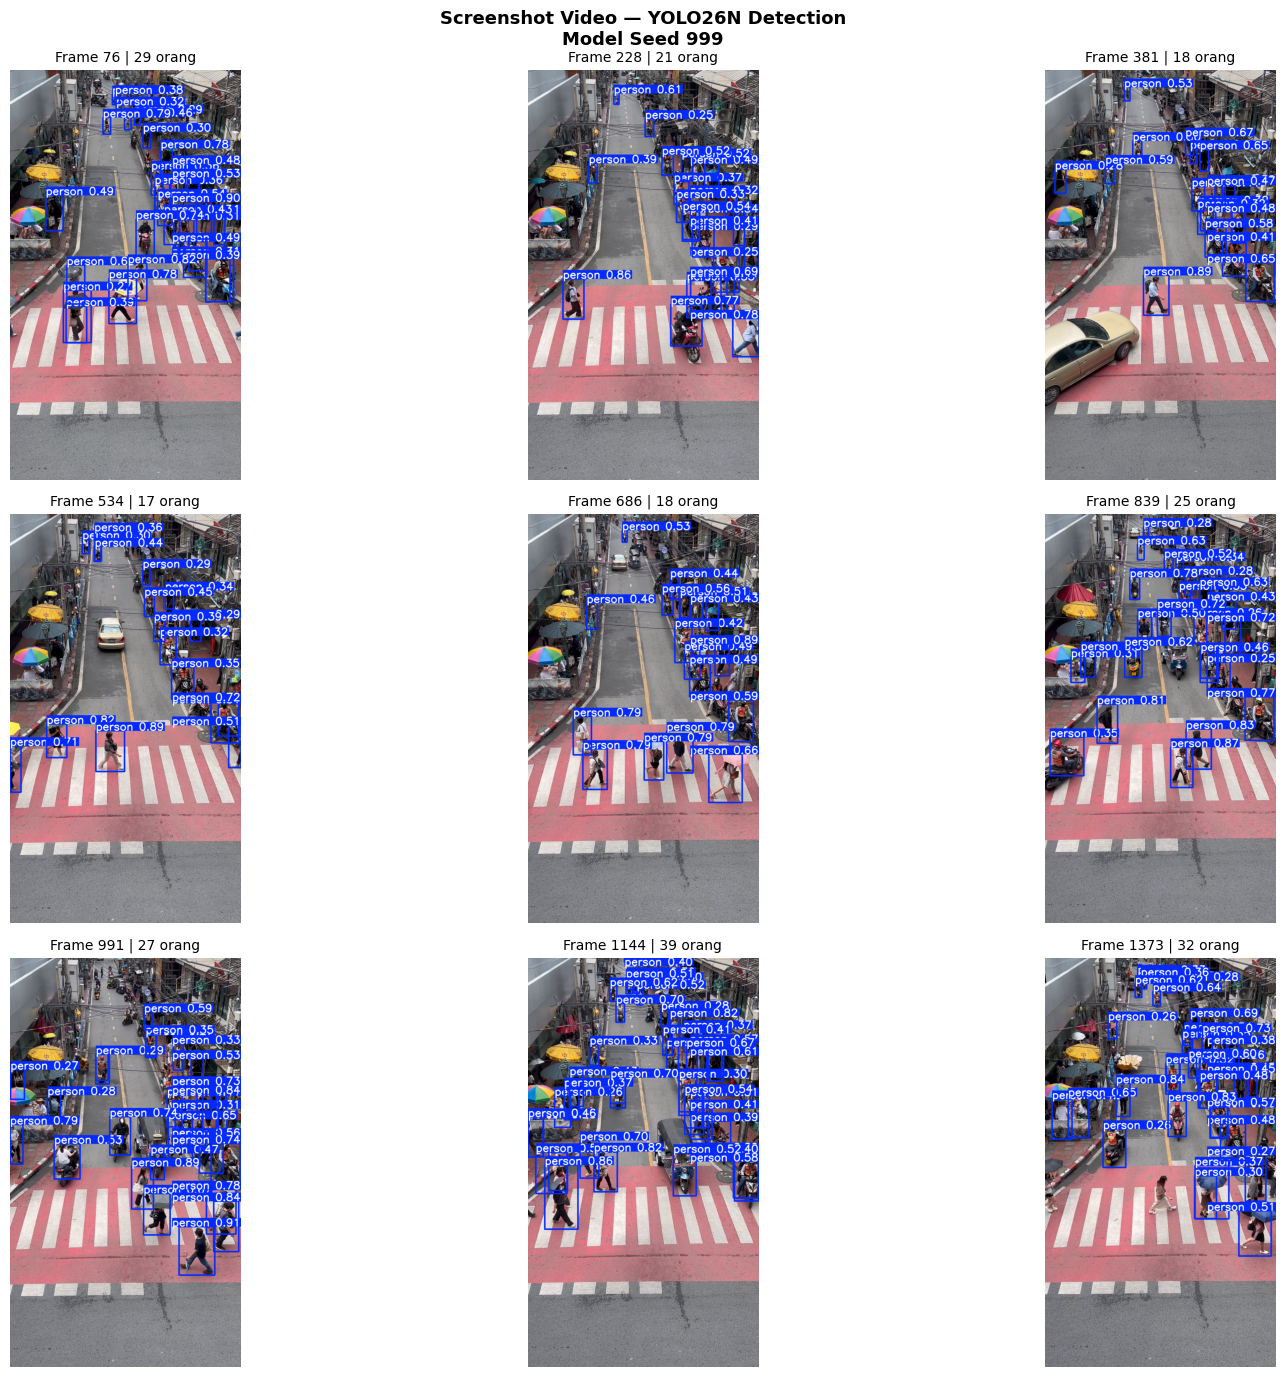

✅ Screenshot tersimpan di Drive!


In [ ]:
# Ambil frame terbaik dari video sebagai screenshot
# untuk dokumentasi skripsi

if 'VIDEO_INPUT' not in dir() or \
   not os.path.exists(VIDEO_INPUT):
    print("❌ Upload video dulu di cell sebelumnya")
else:
    cap    = cv2.VideoCapture(VIDEO_INPUT)
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Ambil 9 frame dari titik berbeda
    indices = [int(total * p) for p in
               [0.05, 0.15, 0.25, 0.35, 0.45,
                0.55, 0.65, 0.75, 0.90]]

    fig, axes = plt.subplots(3, 3,
                             figsize=(18, 14))
    axes = axes.flatten()

    print("Mengambil screenshot terbaik...")

    for i, fi in enumerate(indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
        ret, frame = cap.read()
        if not ret: continue

        results = model.predict(
            frame,
            conf    = 0.25,
            iou     = 0.35,
            classes = [0],
            verbose = False)[0]

        img_result = cv2.cvtColor(
            results.plot(), cv2.COLOR_BGR2RGB)
        n_det      = len(results.boxes)

        axes[i].imshow(img_result)
        axes[i].set_title(
            f"Frame {fi} | {n_det} orang",
            fontsize=10)
        axes[i].axis("off")

    cap.release()

    plt.suptitle(
        f"Screenshot Video — {MODEL_NAME.upper()} Detection\n"
        f"Model Seed {BEST_SEED}",
        fontsize=13, fontweight='bold')
    plt.tight_layout()

    ss_path = "/content/demo_output/screenshot_video.png"
    plt.savefig(ss_path, dpi=150,
                bbox_inches='tight')
    plt.show()

    shutil.copy(ss_path,
                f"{DRIVE_DIR}/screenshot_video.png")
    print("✅ Screenshot tersimpan di Drive!")


In [ ]:
# Analisis statistik deteksi dari video
# berguna untuk BAB 4 skripsi

if 'VIDEO_INPUT' not in dir() or \
   not os.path.exists(VIDEO_INPUT):
    print("❌ Upload video dulu di cell sebelumnya")
else:
    cap    = cv2.VideoCapture(VIDEO_INPUT)
    fps    = cap.get(cv2.CAP_PROP_FPS)
    total  = int(cap.get(
        cv2.CAP_PROP_FRAME_COUNT))

    detections_per_frame = []
    conf_per_frame       = []
    times                = []
    frame_count          = 0

    print("Analisis statistik video...")

    while True:
        ret, frame = cap.read()
        if not ret: break
        frame_count += 1

        start   = time.time()
        results = model.predict(
            frame,
            conf    = 0.25,
            iou     = 0.35,
            classes = [0],
            verbose = False)[0]
        times.append(time.time() - start)

        n_det = len(results.boxes)
        detections_per_frame.append(n_det)

        if n_det > 0:
            avg_c = float(
                results.boxes.conf.mean())
            conf_per_frame.append(avg_c)

        if frame_count % 50 == 0:
            print(f"  {frame_count}/{total}")

    cap.release()

    # Hitung statistik
    det_arr = np.array(detections_per_frame)
    t_arr   = np.array(times)

    print(f"\n{'='*55}")
    print(f"STATISTIK DETEKSI VIDEO")
    print(f"{'='*55}")
    print(f"Total frame        : {frame_count}")
    print(f"Durasi video       : "
          f"{frame_count/fps:.1f} detik")
    print(f"\nDeteksi per frame:")
    print(f"  Rata-rata        : "
          f"{det_arr.mean():.2f} orang")
    print(f"  Std dev          : "
          f"{det_arr.std():.2f}")
    print(f"  Min              : {det_arr.min()}")
    print(f"  Max              : {det_arr.max()}")
    print(f"  Frame tanpa det  : "
          f"{(det_arr==0).sum()} "
          f"({(det_arr==0).mean()*100:.1f}%)")
    print(f"  Frame ada deteksi: "
          f"{(det_arr>0).sum()} "
          f"({(det_arr>0).mean()*100:.1f}%)")
    if conf_per_frame:
        conf_arr = np.array(conf_per_frame)
        print(f"\nConfidence rata-rata: {conf_arr.mean()*100:.2f}%")
    print(f"\nKecepatan inferensi:")
    print(f"  Rata-rata FPS    : {1.0/t_arr.mean():.1f}")
    print(f"  Rata-rata ms     : {t_arr.mean()*1000:.1f} ms")


Analisis statistik video...
  50/1526
  100/1526
  150/1526
  200/1526
  250/1526
  300/1526
  350/1526
  400/1526
  450/1526
  500/1526
  550/1526
  600/1526
  650/1526
  700/1526
  750/1526
  800/1526
  850/1526
  900/1526
  950/1526
  1000/1526
  1050/1526
  1100/1526
  1150/1526
  1200/1526
  1250/1526
  1300/1526
  1350/1526
  1400/1526
  1450/1526
  1500/1526

STATISTIK DETEKSI VIDEO
Total frame        : 1526
Durasi video       : 50.9 detik

Deteksi per frame:
  Rata-rata        : 25.88 orang
  Std dev          : 6.56
  Min              : 8
  Max              : 47
  Frame tanpa det  : 0 (0.0%)
  Frame ada deteksi: 1526 (100.0%)

Confidence rata-rata: 49.32%

Kecepatan inferensi:
  Rata-rata FPS    : 58.4
  Rata-rata ms     : 17.1 ms


demo onnx

In [ ]:
# ============================================================
# FIX ONNX RUNTIME UNTUK TESLA T4 + CUDA 12.8
# ============================================================

!pip uninstall -y onnxruntime onnxruntime-gpu -q

# ORT 1.26.x menggunakan build CUDA 12.8
!pip install -q onnxruntime-gpu==1.26.0 onnx

print("✅ ONNX Runtime GPU 1.26.0 terpasang")
print("⚠️ Sekarang lakukan: Runtime > Restart session")


✅ ONNX Runtime GPU 1.26.0 terpasang
⚠️ Sekarang lakukan: Runtime > Restart session


In [ ]:
# ============================================================
# CEK ENVIRONMENT SETELAH RESTART
# ============================================================

import torch
import onnxruntime as ort

print("=" * 60)
print("ENVIRONMENT CHECK")
print("=" * 60)

print("GPU       :", torch.cuda.get_device_name(0))
print("CUDA      :", torch.version.cuda)
print("ORT       :", ort.__version__)
print("Providers :", ort.get_available_providers())


ENVIRONMENT CHECK
GPU       : Tesla T4
CUDA      : 12.8
ORT       : 1.28.0
Providers : ['AzureExecutionProvider', 'CPUExecutionProvider']


In [ ]:
# ============================================================
# TES MODEL ONNX PADA TESLA T4
# ============================================================

import os
import numpy as np
from ultralytics import YOLO

MODEL_PATH = (
    "/content/drive/MyDrive/skripsi_yolo26n/"
    "experiments_5seed/seed_42/weights/best.onnx"
)

print("Model:", MODEL_PATH)

model = YOLO(MODEL_PATH, task="detect")

print("✅ Model berhasil dimuat")
print("Kelas:", model.names)

# Dummy image
dummy = np.zeros(
    (640, 640, 3),
    dtype=np.uint8
)

print("\nMenjalankan inferensi pada Tesla T4...")

results = model.predict(
    source=dummy,
    imgsz=640,
    device=0,
    conf=0.25,
    verbose=False
)

print("\n" + "=" * 60)
print("✅ BERHASIL!")
print("=" * 60)
print("Model  : YOLO26n ONNX")
print("GPU    : Tesla T4")
print("Input  : 640 × 640")
print("Class  :", model.names)


Model: /content/drive/MyDrive/skripsi_yolo26n/experiments_5seed/seed_42/weights/best.onnx
✅ Model berhasil dimuat
Loading /content/drive/MyDrive/skripsi_yolo26n/experiments_5seed/seed_42/weights/best.onnx for ONNX Runtime inference...
WARNING ⚠️ CUDA requested but CUDAExecutionProvider not available. Using CPU...
Using ONNX Runtime 1.28.0 with CPUExecutionProvider
Kelas: {0: 'person'}

Menjalankan inferensi pada Tesla T4...
Loading /content/drive/MyDrive/skripsi_yolo26n/experiments_5seed/seed_42/weights/best.onnx for ONNX Runtime inference...
WARNING ⚠️ CUDA requested but CUDAExecutionProvider not available. Using CPU...
Using ONNX Runtime 1.28.0 with CPUExecutionProvider

✅ BERHASIL!
Model  : YOLO26n ONNX
GPU    : Tesla T4
Input  : 640 × 640
Class  : {0: 'person'}


In [ ]:
# ============================================================
# DEMO VIDEO YOLO ONNX - TESLA T4
# ============================================================

import os
import time
import cv2
import torch
import numpy as np

from ultralytics import YOLO
from google.colab import files
from IPython.display import Video, display

# ============================================================
# CEK GPU
# ============================================================

print("=" * 60)
print("GPU CHECK")
print("=" * 60)

if not torch.cuda.is_available():
    raise RuntimeError("❌ CUDA tidak tersedia!")

print("✅ GPU :", torch.cuda.get_device_name(0))
print("✅ CUDA:", torch.version.cuda)

# ============================================================
# MODEL
# ============================================================

MODEL_PATH = (
    "/content/drive/MyDrive/skripsi_yolo26n/"
    "experiments_5seed/seed_42/weights/best.onnx"
)

print("\nMemuat model:")
print(MODEL_PATH)

model = YOLO(
    MODEL_PATH,
    task="detect"
)

print("✅ Model ONNX berhasil dimuat")
print("Kelas:", model.names)

# ============================================================
# UPLOAD VIDEO
# ============================================================

print("\nSilakan upload video untuk demo:")

uploaded = files.upload()

video_name = list(uploaded.keys())[0]
video_path = f"/content/{video_name}"

print("\n✅ Video:")
print(video_path)

# ============================================================
# OUTPUT
# ============================================================

OUTPUT_DIR = "/content/demo_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

output_name = "demo_onnx_tesla_t4.mp4"
output_path = os.path.join(
    OUTPUT_DIR,
    output_name
)

# ============================================================
# BACA VIDEO
# ============================================================

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise RuntimeError("❌ Video tidak dapat dibuka!")

width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = cap.get(cv2.CAP_PROP_FPS)
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"\nResolusi : {width}x{height}")
print(f"FPS asli : {fps:.1f}")
print(f"Total    : {total} frame")

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out    = cv2.VideoWriter(
    output_path, fourcc, fps, (width, height)
)

result_dir = f"{OUTPUT_DIR}/result"
os.makedirs(result_dir, exist_ok=True)
result_video_path = f"{result_dir}/{video_name}"
out2 = cv2.VideoWriter(
    result_video_path, fourcc, fps, (width, height)
)

frame_count = 0
proc_times  = []

print("\nMemproses video dengan ONNX...")

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_count += 1

    start = time.time()
    results = model.predict(
        source=frame,
        imgsz=640,
        conf=0.25,
        device=0,
        verbose=False
    )[0]
    proc_times.append(time.time() - start)

    annotated = results.plot()
    out.write(annotated)
    out2.write(annotated)

    if frame_count % 50 == 0:
        print(f"  {frame_count}/{total}")

cap.release()
out.release()
out2.release()

avg_fps = 1.0 / np.mean(proc_times)
print(f"\n✅ Selesai! Rata-rata FPS: {avg_fps:.1f}")
print(f"   Tersimpan: {result_video_path}")


GPU CHECK
✅ GPU : Tesla T4
✅ CUDA: 12.8

Memuat model:
/content/drive/MyDrive/skripsi_yolo26n/experiments_5seed/seed_42/weights/best.onnx
✅ Model ONNX berhasil dimuat
Loading /content/drive/MyDrive/skripsi_yolo26n/experiments_5seed/seed_42/weights/best.onnx for ONNX Runtime inference...
WARNING ⚠️ CUDA requested but CUDAExecutionProvider not available. Using CPU...
Using ONNX Runtime 1.28.0 with CPUExecutionProvider
Kelas: {0: 'person'}

Silakan upload video untuk demo:


Saving 13990796_1080_1920_30fps.mp4 to 13990796_1080_1920_30fps.mp4

✅ Video:
/content/13990796_1080_1920_30fps.mp4

Resolusi : 1080x1920
FPS asli : 30.0
Total    : 1526 frame

Memproses video dengan ONNX...
Loading /content/drive/MyDrive/skripsi_yolo26n/experiments_5seed/seed_42/weights/best.onnx for ONNX Runtime inference...
WARNING ⚠️ CUDA requested but CUDAExecutionProvider not available. Using CPU...
Using ONNX Runtime 1.28.0 with CPUExecutionProvider
  50/1526
  100/1526
  150/1526
  200/1526
  250/1526
  300/1526
  350/1526
  400/1526
  450/1526
  500/1526
  550/1526
  600/1526
  650/1526
  700/1526
  750/1526
  800/1526
  850/1526
  900/1526
  950/1526
  1000/1526
  1050/1526
  1100/1526
  1150/1526
  1200/1526
  1250/1526
  1300/1526
  1350/1526
  1400/1526
  1450/1526
  1500/1526

✅ Selesai! Rata-rata FPS: 12.0
   Tersimpan: /content/demo_output/result/13990796_1080_1920_30fps.mp4


In [ ]:
# ============================================================
# TAMPILKAN HASIL VIDEO
# ============================================================

result_video = f"{OUTPUT_DIR}/result/{video_name}"

# Jika nama output berbeda, cari file mp4
if not os.path.exists(result_video):

    import glob

    video_files = glob.glob(
        f"{OUTPUT_DIR}/result/*.mp4"
    )

    if len(video_files) > 0:
        result_video = video_files[0]

print("Video hasil:")
print(result_video)

display(
    Video(
        result_video,
        embed=True,
        width=900
    )
)


Video hasil:
/content/demo_output/result/13990796_1080_1920_30fps.mp4


In [ ]:
# ============================================================
# TAMPILKAN FRAME SETIAP 30 FRAME
# Tanpa menyimpan gambar
# ============================================================

import cv2
import matplotlib.pyplot as plt

FRAME_INTERVAL = 30

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise RuntimeError("❌ Video tidak dapat dibuka!")

fps = cap.get(cv2.CAP_PROP_FPS)

frame_number = 0
shown_count = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    # Tampilkan setiap 30 frame
    if frame_number % FRAME_INTERVAL == 0:

        # Inferensi ONNX menggunakan Tesla T4
        results = model.predict(
            source=frame,
            imgsz=640,
            conf=0.25,
            device=0,
            verbose=False
        )

        # Bounding box hasil deteksi
        annotated_frame = results[0].plot()

        # OpenCV BGR → RGB
        annotated_frame = cv2.cvtColor(
            annotated_frame,
            cv2.COLOR_BGR2RGB
        )

        # Tampilkan
        plt.figure(figsize=(12, 7))
        plt.imshow(annotated_frame)
        plt.title(
            f"Frame {frame_number} | "
            f"Time: {frame_number / fps:.2f} detik"
        )
        plt.axis("off")
        plt.show()

        shown_count += 1

    frame_number += 1

cap.release()

print(f"✅ Selesai — {shown_count} frame ditampilkan.")


perbandingan best.pt dan onnx (menggunakan data validasi CrowdHuman)

In [ ]:
# ============================================================
# PERBANDINGAN YOLO .PT vs .ONNX
# CROWDHUMAN VALIDATION (menggantikan VisDrone)
# ============================================================

import os
import time
import pandas as pd
import torch
import onnxruntime as ort

from pathlib import Path
from ultralytics import YOLO

# ============================================================
# 1. PATH
# ============================================================

DRIVE_DIR = "/content/drive/MyDrive/skripsi_yolo26n"

BEST_PT = (
    f"{DRIVE_DIR}/experiments_5seed/"
    f"seed_42/weights/best.pt"
)

ONNX_PATH = f"{DRIVE_DIR}/best_model_seed42_yolo26n.onnx"

# Dataset validasi: CrowdHuman (hasil konversi di awal notebook)
DATA_YAML = f"{DRIVE_DIR}/dataset_crowdhuman.yaml"

# ============================================================
# 2. KONFIGURASI
# ============================================================

IMG_SIZE = 640
BATCH_SIZE = 16
CONF = 0.001
IOU = 0.7
DEVICE = 0
WORKERS = 2

# ============================================================
# 3. CEK MODEL & DATASET
# ============================================================

print("=" * 70)
print("CEK MODEL & DATASET")
print("=" * 70)

if not os.path.exists(BEST_PT):
    raise FileNotFoundError(
        f"best.pt tidak ditemukan:\n{BEST_PT}"
    )

if not os.path.exists(ONNX_PATH):
    raise FileNotFoundError(
        f"best.onnx tidak ditemukan:\n{ONNX_PATH}"
    )

if not os.path.exists(DATA_YAML):
    raise FileNotFoundError(
        f"dataset_crowdhuman.yaml tidak ditemukan:\n{DATA_YAML}\n"
        f"Jalankan cell pembuatan dataset.yaml di awal notebook."
    )

print("✅ best.pt ditemukan")
print("✅ best.onnx ditemukan")
print("✅ dataset_crowdhuman.yaml ditemukan")

# ============================================================
# 4. CEK GPU
# ============================================================

print("\n" + "=" * 70)
print("GPU / RUNTIME")
print("=" * 70)

print("GPU          :", torch.cuda.get_device_name(0))
print("CUDA         :", torch.version.cuda)
print("ONNX Runtime :", ort.__version__)
print("Providers    :", ort.get_available_providers())

# ============================================================
# 5. FUNGSI EVALUASI
# ============================================================

def evaluate_model(model_path, model_name):

    print("\n" + "=" * 70)
    print(f"EVALUASI: {model_name}")
    print("=" * 70)

    model = YOLO(
        model_path,
        task="detect"
    )

    print("Model:", model_path)
    print("Class:", model.names)

    start = time.perf_counter()

    metrics = model.val(
        data=DATA_YAML,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        conf=CONF,
        iou=IOU,
        device=DEVICE,
        workers=WORKERS,
        plots=False,
        verbose=True
    )

    end = time.perf_counter()

    precision = float(metrics.box.mp)
    recall = float(metrics.box.mr)
    map50 = float(metrics.box.map50)
    map5095 = float(metrics.box.map)

    try:
        map75 = float(metrics.box.map75)
    except:
        map75 = None

    preprocess = float(metrics.speed.get("preprocess", 0))
    inference = float(metrics.speed.get("inference", 0))
    postprocess = float(metrics.speed.get("postprocess", 0))

    latency = preprocess + inference + postprocess
    fps = 1000 / latency if latency > 0 else 0

    validation_time = end - start

    result = {
        "Model": model_name,
        "Precision": precision,
        "Recall": recall,
        "mAP50": map50,
        "mAP50-95": map5095,
        "mAP75": map75,
        "Preprocess (ms)": preprocess,
        "Inference (ms)": inference,
        "Postprocess (ms)": postprocess,
        "Latency (ms)": latency,
        "FPS": fps,
        "Validation Time (s)": validation_time
    }

    print("\nHASIL:")
    print(f"Precision  : {precision*100:.2f}%")
    print(f"Recall     : {recall*100:.2f}%")
    print(f"mAP50      : {map50*100:.2f}%")
    print(f"mAP50-95   : {map5095*100:.2f}%")
    print(f"Latency    : {latency:.2f} ms")
    print(f"FPS        : {fps:.2f}")

    return result

# ============================================================
# 6. EVALUASI PT & ONNX
# ============================================================

result_pt = evaluate_model(BEST_PT, "YOLO26n PyTorch (.pt)")
result_onnx = evaluate_model(ONNX_PATH, "YOLO26n ONNX (.onnx)")

# ============================================================
# 7. TABEL PERBANDINGAN
# ============================================================

results = pd.DataFrame([result_pt, result_onnx])
display_df = results.copy()

for col in ["Precision", "Recall", "mAP50", "mAP50-95", "mAP75"]:
    display_df[col] = display_df[col].apply(
        lambda x: f"{x*100:.2f}%" if pd.notna(x) else "-"
    )

for col in ["Preprocess (ms)", "Inference (ms)", "Postprocess (ms)",
            "Latency (ms)", "FPS", "Validation Time (s)"]:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.2f}")

print("\n" + "=" * 100)
print("PERBANDINGAN PERFORMA")
print("=" * 100)

display(display_df)

# ============================================================
# 8. ANALISIS PERUBAHAN
# ============================================================

pt = result_pt
onnx = result_onnx

print("\n" + "=" * 70)
print("PERUBAHAN SETELAH KONVERSI ONNX")
print("=" * 70)

for metric in ["Precision", "Recall", "mAP50", "mAP50-95"]:
    change = (onnx[metric] - pt[metric]) / pt[metric] * 100
    print(f"{metric:<12}: {change:+.2f}%")

fps_change = (onnx["FPS"] - pt["FPS"]) / pt["FPS"] * 100
latency_change = (onnx["Latency (ms)"] - pt["Latency (ms)"]) / pt["Latency (ms)"] * 100

print(f"{'FPS':<12}: {fps_change:+.2f}%")
print(f"{'Latency':<12}: {latency_change:+.2f}%")

# ============================================================
# 9. KESIMPULAN
# ============================================================

print("\n" + "=" * 70)
print("KESIMPULAN")
print("=" * 70)

map_change = (onnx["mAP50-95"] - pt["mAP50-95"]) / pt["mAP50-95"] * 100

print(f"mAP50-95 PyTorch : {pt['mAP50-95']*100:.2f}%")
print(f"mAP50-95 ONNX    : {onnx['mAP50-95']*100:.2f}%")
print(f"Perubahan        : {map_change:+.2f}%")
print()

if abs(map_change) < 1:
    print("✅ Performa akurasi relatif stabil setelah konversi ke ONNX.")
else:
    print("⚠️ Terdapat perubahan akurasi setelah konversi ke ONNX.")

print(f"\nFPS PyTorch : {pt['FPS']:.2f}")
print(f"FPS ONNX    : {onnx['FPS']:.2f}")

if fps_change > 0:
    print("🚀 ONNX memberikan peningkatan throughput.")
elif fps_change < 0:
    print("⚠️ ONNX memiliki throughput lebih rendah pada pengujian ini.")

# Simpan hasil ke Drive
compare_path = f"{DRIVE_DIR}/perbandingan_pt_vs_onnx.csv"
results.to_csv(compare_path, index=False)
print(f"\n✅ Hasil perbandingan tersimpan: {compare_path}")


CEK MODEL & DATASET
✅ best.pt ditemukan
✅ best.onnx ditemukan
✅ dataset_crowdhuman.yaml ditemukan

GPU / RUNTIME
GPU          : Tesla T4
CUDA         : 12.8
ONNX Runtime : 1.28.0
Providers    : ['AzureExecutionProvider', 'CPUExecutionProvider']

EVALUASI: YOLO26n PyTorch (.pt)
Model: /content/drive/MyDrive/skripsi_yolo26n/experiments_5seed/seed_42/weights/best.pt
Class: {0: 'person'}
Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2716.5±591.0 MB/s, size: 905.4 KB)
val: Scanning /content/yolo_dataset_crowdhuman/labels/val.cache... 4370 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4370/4370 1.1Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 274/274 3.7it/s 1:14
                   all       4370      99481      0.817       0.67      0.782       

,Model,Precision,Recall,mAP50,mAP50-95,mAP75,Preprocess (ms),Inference (ms),Postprocess (ms),Latency (ms),FPS,Validation Time (s)
0,YOLO26n PyTorch (.pt),81.66%,66.96%,78.15%,47.05%,49.11%,1.23,3.22,0.32,4.77,209.46,76.26
1,YOLO26n ONNX (.onnx),81.53%,66.71%,77.81%,46.68%,48.36%,1.50,69.65,0.20,71.35,14.02,397.62



PERUBAHAN SETELAH KONVERSI ONNX
Precision   : -0.15%
Recall      : -0.37%
mAP50       : -0.44%
mAP50-95    : -0.78%
FPS         : -93.31%
Latency     : +1394.50%

KESIMPULAN
mAP50-95 PyTorch : 47.05%
mAP50-95 ONNX    : 46.68%
Perubahan        : -0.78%

✅ Performa akurasi relatif stabil setelah konversi ke ONNX.

FPS PyTorch : 209.46
FPS ONNX    : 14.02
⚠️ ONNX memiliki throughput lebih rendah pada pengujian ini.

✅ Hasil perbandingan tersimpan: /content/drive/MyDrive/skripsi_yolo26n/perbandingan_pt_vs_onnx.csv
